# Steady Oblique Shock 101
**강좌**: *전산유체역학*

## Steady Oblique Shock Problem
10도 경사를 갖는 Wedge에 $M_{\infty}=2$ 인 자유류에 의해 생기는 경사 충격파를 해석한다.

- 무차원화된 자유류 값 (초기 조건)

    $$
    (\rho_{\infty}, u_{\infty}, v_{\infty}, p_{\infty}) = (1, 2, 0, 1/\gamma)
    $$

- 계산 영역
    * `grid` 폴더 내 `wedge.xyz` 파일을 사용한다.

- 경계 조건
   * $i_{\min}$ : Supersonic Inlet
   * $i_{\max}$ : Supersonic Outlet
   * $j_{\min}$ : Wall
   * $j_{\max}$ : Supersonic Outlet

## Steady Problem 개요
- Steady-state 일 때 해를 구하는 문제
    - $t=\infty$, 또는 $\frac{\partial}{\partial t} = 0$
    - 잔차항이 수렴함 $|R| \rightarrow 0$.

- 시간 정확도는 중요하지 않으며 빠르게 Steady-state 에 도달하는 것이 중요함

### Relaxation Methods
- Explicit Runge Kutta scheme
    - 수렴 속도를 가속할 수 있도록 RK 계수 조절 
- Implicit time integration
    - 내재적 시간 적분을 이용하여 시간 간격을 매우 크게 설정함
    - Large Sparse matrix를 해석함
        - Iterative methods : AF-ADI, LU-SGS, GMRes 등

### Convergence acceleration technique
- 수렴 속도를 빠르게 하기 위한 기술
- Local Time stepping
    - 각 격자마다 시간 간격을 다르게 가져감

- Residual smoothing, Multi-grid 등 

## 구현
### Local time stepping
* 각 격자마다 다른 시간으로 수렴시킴
 
    $$
    \Delta t_{i,j}  = CFL \frac{1}{
                      (V_{i,j} \cdot \nabla \xi_{i,j} + a_{i,j} |\nabla \xi_{i,j}|
                     + V_{i,j} \cdot \nabla \eta_{i,j} + a_{i,j} |\nabla \eta_{i,j}|) }
    $$

In [2]:
%%writefile solvers/steady/timestep.py
from nbutils import array
from solvers.fluid import to_primitive

import numba as nb
import numpy as np


def make_timestep(nfx, nfy, jac, si, sj, cfl, gamma=1.4, nvars=4, npads=(1.1)):
    """
    Local Time step calulcation kernel generator
    
    Parameters
    ----------
    nfx - integer
        xi 방향 격자 개수
    nfy - integer
        eta 방향 격자 개수
    jac : array
        Jacobian 크기
    si : array
        xi 방향 Face metric
    sj : array
        eta 방향 Face metric
    cfl : float
        CFL 값
    gamma : float
        비열비 (기본값 1.4)
    nvars: integer
        벡터 크기
    npad : integer
        Solution 벡터의 Padding 개수
        
    Returns
    -------
    _timestep : kernal
        시간 간격 계산 Kerenl
    """
    # Metric at the cell
    sic = 0.5*(si[:, :, :-1] + si[:, :, 1:])*jac
    sjc = 0.5*(sj[:, :-1, :] + sj[:, 1:, :])*jac

    # Magnitude of the metric
    aic = np.linalg.norm(sic, axis=0)
    ajc = np.linalg.norm(sjc, axis=0)
        
    @nb.jit(nopython=True)
    def _timestep(q, dt):
        # Allocate local static array
        qp = array((nvars,))
        
        dtmin = 1e8
        
        for j in range(nfy):
            jy = j + npads[1]
            for i in range(nfx):
                ix = i + npads[0]
                
                to_primitive(q[:, jy, ix], qp)
                rho, u, v, p = qp
                a = np.sqrt(gamma*p/rho)

                ui = sic[0, j, i]*u + sic[1, j, i]*v
                vj = sjc[0, j, i]*u + sjc[1, j, i]*v

                dt[jy, ix]  = cfl  / ((abs(ui) + a*aic[j, i]) + (abs(vj) + a*ajc[j, i]))
    
    return _timestep

Overwriting solvers/steady/timestep.py


- Explicit Euler with Local time stepping

In [3]:
%%writefile solvers/steady/expliciteuler.py
import numpy as np


def make_expliciteuler(nfx, nfy, rhside, nvars=4, npads=(1,1)):
    """
    Euler Explicit 계산 커널 생성
    
    Parameters
    ----------
    nfx - integer
        xi 방향 격자 개수
    nfy - integer
        eta 방향 격자 개수
    rhside : kernel
        우변 계산 커널
    nvars : integer
        벡터 크기 (기본값: 3)
    npad : integer
        Solution 벡터의 Padding 개수
    """
    # Temporal arrays
    du = np.zeros((nvars, nfy+2*npads[1], nfx+2*npads[0]))
    
    # Temporal arrays for flux
    ff = np.zeros((nvars, nfy, nfx+1))
    fg = np.zeros((nvars, nfy+1, nfx))
    
    def _step(dt, u):
        rhside(u, du, ff, fg)
        du[:] = dt*du
        u += du
        
        # Density residual
        return np.linalg.norm(du[0])

    return _step

Overwriting solvers/steady/expliciteuler.py


### 경계 조건 추가
- Slip Wall 조건, 초음속 입/출구 조건 구현 필요

#### Slip Wall BC
- 경계면에서 Normal Velocity가 0 이어야함.
    - $(\mathbf{V}_{L} \cdot \mathbf{n}) \mathbf{n} = \frac{1}{2} (\mathbf{V}_{R} + \mathbf{V}_{L})$
 
- 구현

    $$
    \begin{align}
    u_R &= u_L - 2 (u_L n_x + v_L n_y) n_x\\
    v_R &= v_L - 2 (u_L n_x + v_L n_y) n_y
    \end{align}
    $$

In [4]:
%%writefile solvers/bcs/wall.py
import numba as nb


def make_bc_wall(nvars=4, **kwargs):
    """
    Slip Wall BC function generator

    Parameter
    ---------
    nvars : integer
        변수 개수

    Return
    ------
    _bc : jitted function
        BC function
    """
    @nb.jit(nopython=True)
    def _bc(ul, ur, n):
        # Implement Wall BC!!!
        # After wall
        qn = 2*(ul[1]*n[0] + ul[2]*n[1])
        
        # Before wall (ghost cell)
        ur[1] = ul[1] - qn*n[0]
        ur[2] = ul[2] - qn*n[1]
        
        # At wall
        ur[0] = ul[0]
        ur[3] = ul[3]
        
    return _bc

Overwriting solvers/bcs/wall.py


### Supersonic inflow / outflow
- 초음속에서는 유동의 전파 방향이 같은
- Inflow : Ghost cell은 자유류와 같음
- Outflow : Inner cell과 같음

In [5]:
%%writefile solvers/bcs/sup.py
import numba as nb
import numpy as np


def make_bc_sup_in(nvars=4, rhof=1.0, uf=1.0, vf=0.0, pf=1.0, gamma=1.4):
    """
    Supersonic inlet function generator

    Parameter
    ---------
    nvars : integer
        변수 개수
    rhof : float
        자유류 밀도
    uf : float
        자유류 x 방향 속도
    vf : float
        자유류 y 방향 속도
    pf : float
        자유류 압력
    gamma : float
        비열비 (기본값 : 1.4)

    Return
    ------
    _bc : jitted function
        BC function
    """
    # Conservative variables for free-stream condition
    etf = pf/rhof/(gamma-1) + 0.5*(uf**2 + vf**2)
    qf = np.array([rhof, rhof*uf, rhof*vf, rhof*etf])

    @nb.jit(nopython=True)
    def _bc(ul, ur, nf):
        for k in range(nvars):
            ur[k] = qf[k]
            
    return _bc


def make_bc_sup_out(nvars=4, **kwargs):
    """
    Supersonic outlet function generator

    Parameter
    ---------
    nvars : integer
        변수 개수

    Return
    ------
    _bc : jitted function
        BC function
    """
    @nb.jit(nopython=True)
    def _bc(ul, ur, n):
        for k in range(nvars):
            ur[k] = ul[k]
            
    return _bc

Overwriting solvers/bcs/sup.py


- `solvers.bcs.__init__.py` 에 경계조건 추가

In [6]:
%%writefile solvers/bcs/__init__.py
# Import implemented BC schemes!!!
from solvers.bcs.wall import make_bc_wall
from solvers.bcs.sup import make_bc_sup_in, make_bc_sup_out
from solvers.bcs.zero import make_bc_zero


def get_bc(name, nvars, **kwargs):
    bc = eval('make_bc_'+name)(nvars, **kwargs)
    return bc

Overwriting solvers/bcs/__init__.py


## 실행
- 격자 생성
- 계산 벡터 생성 : $U$
- Kernels 생성
- 초기화
- Main Loop
   * Density Error : $Tol$ 보다 작을 때 까지 계산

     $$
     L_2~Error = \sqrt{\sum_{i,j} (\rho^{n+1}_{i,j} - \rho^n_{i,j})^2} < Tol
     $$

In [7]:
from matplotlib import pylab as plt

# 모듈 로드
from solvers.plot3d import read_plot3d_b, write_q
from solvers.grid import cell_jacobian, face_metric
from solvers.fluid import to_conservative, to_primitive
from solvers.rhside import make_rhside
from solvers.steady.timestep import make_timestep
from solvers.steady.expliciteuler import make_expliciteuler

import numpy as np

plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 150

In [8]:
# Constants
gamma = 1.4
nvars = 4
npads = (1,1)

cfl = 0.5
tol = 1e-5
itmax = 3000

# Schemes
flux = 'rusanov'
limiter = 'first'

# Initial conditions (Primitive)
qpf = (1.0, 2.0, 0.0, 1/gamma)

# BC conditions
bctypes = {
    'imin' : ('sup_in', {'rhof' : 1.0, 'uf' : 2.0, 'vf' : 0.0, 'pf' : 1/gamma, 'gamma': gamma}),
    'imax' : ('sup_out', {}),
    'jmin' : ('wall', {}),
    'jmax' : ('sup_out', {}),
}

# Plot3D 격자 읽기
raw = read_plot3d_b('grids/wedge.xyz')

# Parse point
x, y = raw[:2, 0]

# Compute area and metric
jac = cell_jacobian(x ,y)
si, sj = face_metric(x, y)

# Array
jmx, imx = x.shape
jmx -= 1
imx -= 1
q = np.empty((nvars, jmx+2*npads[1], imx+2*npads[0]))
dt = np.zeros_like(q[0])

# Generate kernels
rhside, bc = make_rhside(imx, jmx, jac, si, sj, flux, bctypes, limiter, gamma, nvars, npads)
timestep = make_timestep(imx, jmx, jac, si, sj, cfl, gamma, nvars, npads)
step = make_expliciteuler(imx, jmx, rhside, nvars, npads)

# Initialize
qf = np.empty(nvars)

to_conservative(qpf, qf)
for n in range(nvars):
    q[n] = qf[n]

hist = []
for i in range(itmax):
    # Compute time step
    timestep(q, dt)
    
    # Step
    err = step(dt, q)
    hist.append([i, err])
    
    # Check Error
    if err < tol:
        print(i, err)
        break
    if (i % 500) == 0:
        print(i, err)
        
print(i, err)

Riemann Solver : rusanov
First-order
0 0.27260417401100223
500 0.0029075871701170135
1000 2.208187992323233e-05
1072 9.96762336847185e-06
1072 9.96762336847185e-06


Text(0.5, 1.0, 'Density Residual History')

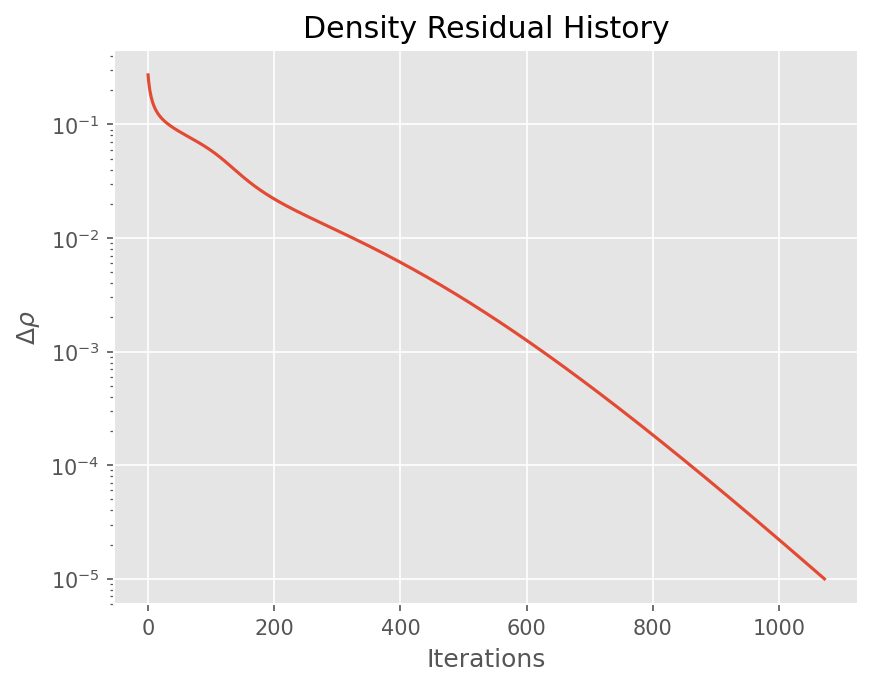

In [9]:
# Residual History
plt.semilogy(*np.array(hist).T)
plt.xlabel("Iterations")
plt.ylabel(r"$\Delta \rho$")
plt.title("Density Residual History")

In [10]:
# Write solution
bc(q)

# Adjust solution array considering padding
_, jqy, iqx = q.shape
ie = (0, iqx)
je = (0, jqy)

if npads[0] > 1:
    ie = npads[0] - 1, -(npads[0] - 1)
    
if npads[1] > 1:
    je = npads[1] - 1, -(npads[1] - 1)

write_q('sol.q', q[:, je[0]:je[1], ie[0]:ie[1]])

## 가시화
- Paraview 또는 Tecplot으로 유동을 확인하다.

    ```bash
    user@localhost: ~$ paraview grids/wedge.xyz
    ```

    - `sol.q` 파일을 Q File Name으로 설정한다.